# Analisis de Sentimientos en reseñas de canciones digitales



## Librerias

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings

warnings.filterwarnings("ignore")

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/jhonattan.reales/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Datos

In [8]:
# Descargamos el conjunto de reseñas desde nuestro repositorio
# !wget -O Digital_Music_5.json https://raw.githubusercontent.com/Can0land/NLP-Laboratory/refs/heads/main/Digital_Music_5.json

--2026-02-15 09:06:58--  https://raw.githubusercontent.com/Can0land/NLP-Laboratory/refs/heads/main/Digital_Music_5.json
Resolviendo raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Conectando con raw.githubusercontent.com (raw.githubusercontent.com)[185.199.109.133]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 74747848 (71M) [text/plain]
Grabando a: «Digital_Music_5.json»

Digital_Music_5.jso 100%[===================>]  71.28M  5.86MB/s    en 12s     

2026-02-15 09:07:10 (5.84 MB/s) - «Digital_Music_5.json» guardado [74747848/74747848]



Cargamos el dataset de reseñas, teniendo en cuenta que es un archivo json

In [9]:
df = pd.read_json("./Digital_music_5.json", lines=True)
df.head(3)

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
0,5,3.0,True,"06 3, 2013",A2TYZ821XXK2YZ,3426958910,{'Format:': ' Audio CD'},Garrett,"This is awesome to listen to, A must-have for ...",Slayer Rules!,1370217600,NaN
1,5,NaN,True,"10 11, 2014",A3OFSREZADFUDY,3426958910,{'Format:': ' Audio CD'},Ad,bien,Five Stars,1412985600,NaN
2,5,NaN,True,"02 11, 2014",A2VAMODP8M77NG,3426958910,{'Format:': ' Audio CD'},JTGabq,It was great to hear the old stuff again and I...,SLAYER!!!!!!!!!!!!!!!!!!!!!,1392076800,NaN


Eliminamos columnas que no son necesarias para nuestro analisis de sentimientos

In [10]:
df_music = df.drop(
    [
        "reviewTime",
        "unixReviewTime",
        "reviewerID",
        "image",
        "asin",
        "reviewerName",
        "verified",
    ],
    axis=1,
)
df_music.sample(10)

,overall,vote,style,reviewText,summary
36369,5,NaN,{'Format:': ' MP3 Music'},"Thank you, thank you Amazon. Found this song i...",one of my favorite songs
119736,5,NaN,{'Format:': ' MP3 Music'},Fantastic mp3-I absolutely LOVE this song!!!,Love this mp3!!!
49471,5,NaN,{'Format:': ' MP3 Music'},"Even though an older song, I have always loved...",I Try
23639,5,NaN,{'Format:': ' MP3 Music'},Too bad they used it for that animal cruelty c...,Used to like it.
45917,5,2.0,{'Format:': ' MP3 Music'},I remember hearing this song back in the day a...,Great Song
72425,5,NaN,{'Format:': ' Audio CD'},"I have all the Nirvana albums, and this one is...",vintage Nirvana
17051,5,NaN,{'Format:': ' MP3 Music'},A really underrated song by Chicago in my opin...,Rock On
155788,5,NaN,{'Format:': ' MP3 Music'},Good music.,Five Stars
91063,4,NaN,{'Format:': ' MP3 Music'},good price,Four Stars
79448,5,NaN,{'Format:': ' MP3 Music'},Awesome,Five Stars


Nuestra tabla de reseñas ahora cuenta con las siguientes 5 columnas:

- overall: calificación general del producto (1-5)
- vote: calificación del comentario por parte de otros usuarios
- style: estilo del producto
- reviewText: texto de la reseña
- summary: resumen de la reseña

### Limpieza de datos
Verificamos la calidad de las columnas, y limpiamos los datos

In [11]:
df_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169781 entries, 0 to 169780
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   overall     169781 non-null  int64  
 1   vote        7611 non-null    float64
 2   style       157989 non-null  object 
 3   reviewText  169623 non-null  object 
 4   summary     169745 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 6.5+ MB


A continuación, aplicaremos algunos pasos de limpieza

In [12]:
# Eliminamos todas las filas con valores nulos en las columnas style y revieText
df_music = df_music.dropna(subset=["style", "reviewText"])

# Modificamos la columna style para que solo tengas valores tipo texto, sin diccionario
df_music["style"] = df_music["style"].apply(
    lambda x: x.get("Format:") if isinstance(x, dict) else None
)
# A la columna vote, los valores nulos los cambiamos por 0
df_music["vote"] = df_music["vote"].fillna(0)

# las columnas tipo texto, le cambiamos las mayusculas por minusculas y le quitamos espamos en blanco al princpio o al final
df_music["reviewText"] = df_music["reviewText"].str.lower().str.strip()
df_music["summary"] = df_music["summary"].str.lower().str.strip()

In [13]:
df_music.sample(2)

,overall,vote,style,reviewText,summary
68851,3,0.0,MP3 Music,good song,three stars
142953,1,0.0,MP3 Music,purchased by an ex-friend who figured out how ...,one star


## EDA
Realizar un EDA para entender el comportamiento y posibles valores de cada variable.


### Variables no tipo texto

In [15]:
df_music.describe()

,overall,vote
count,157835.000000,157835.000000
mean,4.707840,0.374473
std,0.701844,4.417204
min,1.000000,0.000000
25%,5.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,461.000000


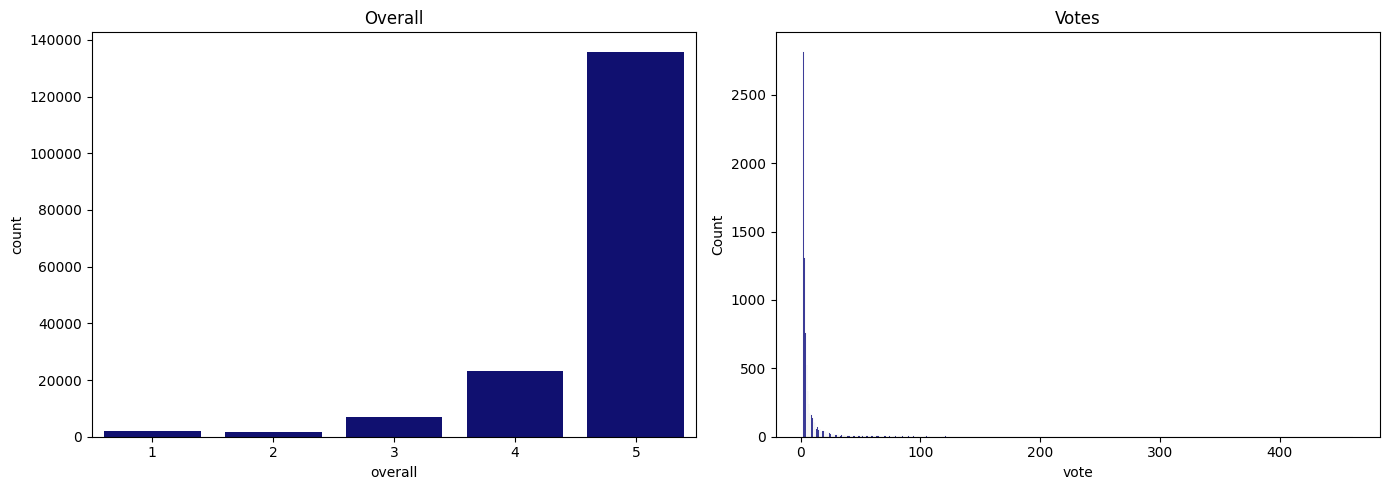

In [20]:
# Graficamos el conteo de las puntuaciones y los votos de cada reseña
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="overall", color="navy", ax=axes[0])
axes[0].set_title("Overall")

sns.histplot(data=df, x="vote", color="navy", ax=axes[1])
axes[1].set_title("Votes")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x=)

### Variables tipo texto

In [14]:
"""
De cada variable con textos (principalmente reviewText), obtendremos:
- El numero de tokens (no espacios ni puntuaciones) y luego graficaremos dicha distribución de manera univariada y bivariada junto a la puntuación de la reseña
- El numero de sentencias y graficamos.
- El numero promedio de palabras por oración, tanto global como cruzado con la puntuación.
- Graficaremos una nube de  palabras para determinar las palabras mas frecuentes, tanto a nivel general, como cruzado con la puntuación.
"""

'\nDe cada variable con textos (principalmente reviewText), obtendremos:\n- El numero de tokens (no espacios ni puntuaciones) y luego graficaremos dicha distribución de manera univariada y bivariada junto a la puntuación de la reseña\n- El numero de sentencias y graficamos.\n- El numero promedio de palabras por oración, tanto global como cruzado con la puntuación.\n- Graficaremos una nube de  palabras para determinar las palabras mas frecuentes, tanto a nivel general, como cruzado con la puntuación.\n'

### Pre-procesamiento

## Analisis de sentimiento

### Vard modelo

### modelo #2

## Analisis de resultados

## Conclusion